# FLEXtopo Calibration and Validation


In [5]:
# General python

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime
from Weigfun import Weigfun
from plateau import plateau_func
import warnings
warnings.filterwarnings('ignore')
# import ewatercycle.forcing
# import ewatercycle.observation.grdc
# import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print
import shutil
import xarray as xr

## Landscape parameters

Each landscape (plateau, hillslope, wetland) has own parameters that need to be calibrated

### Parameter overview
| Unit | Par[0] | Par[1] | Par[2] | Par[3] | Par[4] | Par[5] |
|------|--------|--------|--------|--------|--------|--------|
| Plateau | Imax | Ce | Sumax | beta | Pmax | Kf |
| Hillslope | Imax | Ce | Sumax | beta | D | Kf |
| Wetland | Imax | Ce | Sumax | beta | Cmax | Kf |

Catchment-level: `ParCatchment = [Ks, T_lag]`

### Hillslope

In [6]:
def hillslope_func(timestep, Par, forcing, Fluxes, States):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	D = Par[4]
	Kf = Par[5]
	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']

	t_max = len(Prec)
	Si = States[:, 0]
	Su = States[:, 1]
	Sf = States[:, 2]

	Ei_dt = Fluxes[:, 0]
	Ea_dt = Fluxes[:, 1]
	Qf_dt = Fluxes[:, 2]
	Qus_dt = Fluxes[:, 3]

	dt = 1
	t = timestep

	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt

	# Interception Reservoir
	if P_dt > 0:
		Si[t] = Si[t] + P_dt
		Pe_dt = max(0, Si[t] - I_max)
		Si[t] = Si[t] - Pe_dt
		Ei_dt[t] = 0
	else:
		# Evaporation only when there is no rainfall
		Pe_dt = 0
		Ei_dt[t] = min(Ep_dt, Si[t])
		Si[t] = Si[t] - Ei_dt[t]

	if t < t_max - 1:
		Si[t + 1] = Si[t]

	# Unsaturated Reservoir
	if Pe_dt > 0:
		rho = (Su[t] / Su_max) ** beta
		Su[t] = Su[t] + (1 - rho) * Pe_dt
		Quf_dt = rho * Pe_dt
	else:
		Quf_dt = 0

	# Transpiration
	Ep_dt = max(0, Ep_dt - Ei_dt[t])
	Ea_dt[t] = Ep_dt * (Su[t] / (Su_max * Ce))
	Ea_dt[t] = min(Ea_dt[t], Su[t])
	Su[t] = Su[t] - Ea_dt[t]
	if t < t_max - 1:
		Su[t + 1] = Su[t]


	# Preferential Percolation
	Qus_dt[t] = D * Quf_dt


	# Fast Reservoir
	Sf[t] = Sf[t] + (1 - D) * Quf_dt
	Qf_dt[t] = dt * Kf * Sf[t]
	Sf[t] = Sf[t] - min(Qf_dt[t], Sf[t])
	if t < t_max - 1:
		Sf[t + 1] = Sf[t]

	# Save output
	States[:, 0] = Si
	States[:, 1] = Su
	States[:, 2] = Sf

	Fluxes[:, 0] = Ei_dt
	Fluxes[:, 1] = Ea_dt
	Fluxes[:, 2] = Qf_dt
	Fluxes[:, 3] = Qus_dt

	return (Fluxes, States)

### Wetlands

In [7]:
def wetland_func(timestep, Par, forcing, Fluxes, States, Ss, landscape_per):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	C_max = Par[4]
	Kf = Par[5]

	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']


	t_max = len(Prec)
	Si = States[:,0]
	Su = States[:,1]
	Sf = States[:,2]

	Ei_dt = Fluxes[:,0]
	Ea_dt = Fluxes[:,1]
	Qf_dt = Fluxes[:,2]

	dt = 1
	t = timestep

	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt

	# Interception Reservoir
	if P_dt > 0:
		Si[t] = Si[t] + P_dt
		Pe_dt = max(0, Si[t]-I_max)
		Si[t] = Si[t] - Pe_dt
		Ei_dt[t] = 0
	else:
	# Evaporation only when there is no rainfall
		Pe_dt = 0
		Ei_dt[t] = min(Ep_dt, Si[t])
		Si[t] = Si[t] - Ei_dt[t]

	if t < t_max - 1:
		Si[t+1] = Si[t]


	# Unsaturated Reservoir
	if Pe_dt > 0:
		rho = (Su[t]/Su_max) ** beta
		Su[t] = Su[t] + (1-rho) * Pe_dt
		Quf_dt = rho * Pe_dt
	else:
		Quf_dt = 0


	# Transpiration
	Ep_dt = max(0, Ep_dt-Ei_dt[t])
	Ea_dt[t] = Ep_dt * (Su[t]/(Su_max*Ce))
	Ea_dt[t] = min(Ea_dt[t], Su[t])
	Su[t] = Su[t] - Ea_dt[t]


	# Capillary rise
	Qr_dt = (1-Su[t]/Su_max) * C_max * dt
	Qr_dt = min(Qr_dt, Ss[t] /landscape_per) #check if the groundwater has enough water (note: you need to use the landscape percentage!!!)

	if ((Su[t] + Qr_dt) > Su_max):
		Qr_dt = Su_max - Su[t]


	Su[t] = Su[t] + Qr_dt
	Ss[t] = Ss[t] - Qr_dt * landscape_per

	if t < t_max - 1:
		Su[t+1] = Su[t]

	# Fast Reservoir
	Sf[t] = Sf[t] + Quf_dt
	Qf_dt[t] = dt * Kf * Sf[t]
	Sf[t] = Sf[t]- min(Qf_dt[t], Sf[t])
	if t < t_max-1:
		Sf[t+1] = Sf[t]


	# Save output
	States[:,0] = Si
	States[:,1] = Su
	States[:,2] = Sf

	Fluxes[:,0] = Ei_dt
	Fluxes[:,1] = Ea_dt
	Fluxes[:,2] = Qf_dt

	return(Fluxes, States, Ss)

### Plateau

In [8]:
def plateau_func(timestep, Par, forcing, Fluxes, States):
 
    I_max  = Par[0]
    Ce     = Par[1]
    Su_max = Par[2]
    beta   = Par[3]
    P_max  = Par[4]   # max percolation to slow reservoir
    Kf     = Par[5]
 
    Prec = forcing['Prec']
    Etp  = forcing['Etp']
 
    t_max = len(Prec)
    Si    = States[:, 0]
    Su    = States[:, 1]
    Sf    = States[:, 2]
 
    Ei_dt  = Fluxes[:, 0]
    Ea_dt  = Fluxes[:, 1]
    Qf_dt  = Fluxes[:, 2]
    Qus_dt = Fluxes[:, 3]
 
    dt    = 1
    t     = timestep
    P_dt  = Prec[t] * dt
    Ep_dt = Etp[t] * dt
 
    #Interception reservoir
    # Throughfall: precip that exceeds the available interception capacity
    Pe_dt    = max(0, P_dt - max(0, I_max - Si[t]))
    Ei_dt[t] = min(Ep_dt, Si[t] + P_dt - Pe_dt)
 
    if t < t_max - 1:
        Si_new = Si[t] + dt * (P_dt - Pe_dt - Ei_dt[t])
        # FIX: if Si would exceed I_max, route the overflow as additional throughfall
        if Si_new > I_max:
            Pe_dt  += Si_new - I_max
            Si[t+1] = I_max
        else:
            Si[t+1] = max(0, Si_new)
 
    Ep_remain = max(0, Ep_dt - Ei_dt[t])
 
    #Unsaturated reservoir
    Cr    = (Su[t] / Su_max) ** beta
    Pu_dt = (1 - Cr) * Pe_dt   # infiltration into Su
    Qu_dt = Cr * Pe_dt          # direct runoff to fast reservoir
 
    # Transpiration
    Ea_dt[t] = Ce * (Su[t] / Su_max) * Ep_remain
 
    if t < t_max - 1:
        Su_new    = Su[t] + dt * (Pu_dt - Ea_dt[t])
        # Percolation to slow reservoir capped at P_max and available storage
        Qus_dt[t] = min(P_max, max(0, Su_new))
        Su_new   -= Qus_dt[t]
        # FIX: if Su would go negative, route the deficit as additional fast runoff
        if Su_new < 0:
            Qu_dt  += abs(Su_new)
            Su[t+1] = 0
        else:
            Su[t+1] = Su_new
    else:
        Qus_dt[t] = min(P_max, max(0, Su[t]))
 
    #Fast reservoir
    # FIX: compute outflow from Sf[t] (not Sf[t+1]) to avoid forward-time error
    Qf_dt[t] = Kf * Sf[t]
    if t < t_max - 1:
        Sf_new = Sf[t] + dt * Qu_dt - dt * Qf_dt[t]
        # FIX: if Sf would go negative, reduce outflow to what is available
        if Sf_new < 0:
            Qf_dt[t] = Sf[t] + dt * Qu_dt
            Sf[t+1]  = 0
        else:
            Sf[t+1] = Sf_new
 
    States[:, 0] = Si;  States[:, 1] = Su;  States[:, 2] = Sf
    Fluxes[:, 0] = Ei_dt;  Fluxes[:, 1] = Ea_dt
    Fluxes[:, 2] = Qf_dt;  Fluxes[:, 3] = Qus_dt
 
    return Fluxes, States

### Flextopo model 

In [9]:
def FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscapes):

	# Parameters and constants
	T_lag = ParCatchment[1]
	Ks = ParCatchment[0]
	dt = 1
	t_max = len(forcing['Qo'])

	# Initialize states
	States_plateau = np.zeros((t_max,3))
	States_hillslope = np.zeros((t_max,3))
	States_wetland = np.zeros((t_max,3))
	Ss = np.zeros((t_max,1))

	# Initialize fluxes
	Fluxes_plateau = np.zeros((t_max,4))
	Fluxes_hillslope = np.zeros((t_max,4))
	Fluxes_wetland = np.zeros((t_max,3))
	Qs_dt = np.zeros(t_max)
	Q_tot_dt = np.zeros(t_max)

	# Loop over time
	for t in range(0,t_max):

		# Plateau
		Fluxes_plateau, States_plateau = plateau_func(t, ParPlateau, forcing, Fluxes_plateau, States_plateau)
		# Hillslope
		Fluxes_hillslope, States_hillslope = hillslope_func(t, ParHillslope, forcing, Fluxes_hillslope, States_hillslope)

		# Wetland
		Fluxes_wetland, States_wetland, Ss = wetland_func(t, ParWetland, forcing, Fluxes_wetland, States_wetland, Ss, landscapes[2])

		# Slow Reservoir
		'''UPDATE'''
		Ss[t] = Ss[t] + Fluxes_plateau[t, 3] * landscapes[0] + Fluxes_hillslope[t, 3] * landscapes[1]
		Qs_dt = dt * Ks * Ss[t]
		Ss[t] = Ss[t] - min(Qs_dt,Ss[t])
		if t < t_max - 1:
			Ss[t+1] = Ss[t]

		'''UPDATE'''
		Q_tot_dt[t] = Qs_dt + Fluxes_plateau[t,2] * landscapes[0] + Fluxes_hillslope[t,2] * landscapes[1] + Fluxes_wetland[t,2] * landscapes[2]

	# Offset Q
	weigths = Weigfun(T_lag)

	Qm = np.convolve(Q_tot_dt, weigths)
	Qm = Qm[0:t_max]

	return(Qm)

## Landscapes

In QGIS we made HAND (Height Above Nearest Drainage): separates wetlands (low-lying) from upland units and the slope which separates plateaus from steeper hillslopes.

In [10]:
DEM = np.genfromtxt('DEM_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
slope = np.genfromtxt('slope_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
hand = np.genfromtxt('HAND_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
basin = np.genfromtxt('basin_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)

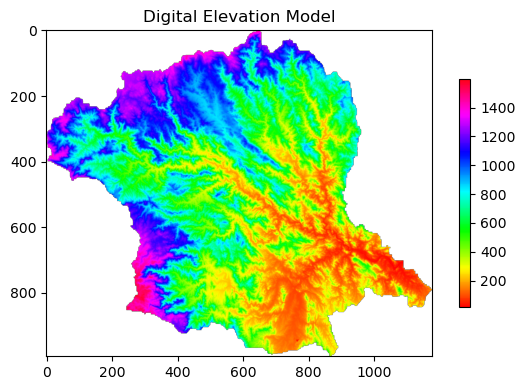

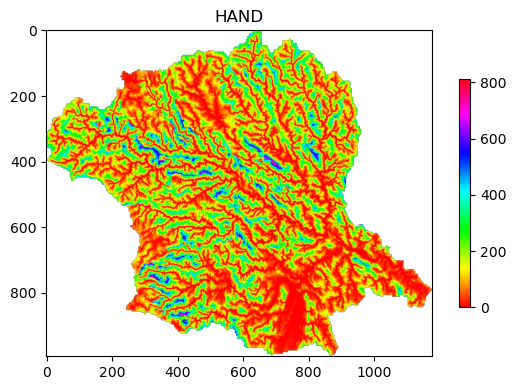

In [11]:
#plot DEM
fig, ax = plt.subplots(figsize=(6,4))
ax.set_title('Digital Elevation Model')
DEM[DEM==-9999] = np.nan
im = ax.imshow(DEM, cmap='hsv')
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

# plot HAND
fig, ax = plt.subplots(figsize=(6,4))
ax.set_title('HAND')
hand[hand==-9999] = np.nan
im = ax.imshow(hand, cmap='hsv')
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

## Classification
This is the classification we made:
| Class | Condition |
|-------|-----------|
| Wetland | HAND ≤ 5 m AND slope ≤ 9% |
| Plateau | HAND > 5 m AND slope ≤ 9% |
| Hillslope | slope > 9% |


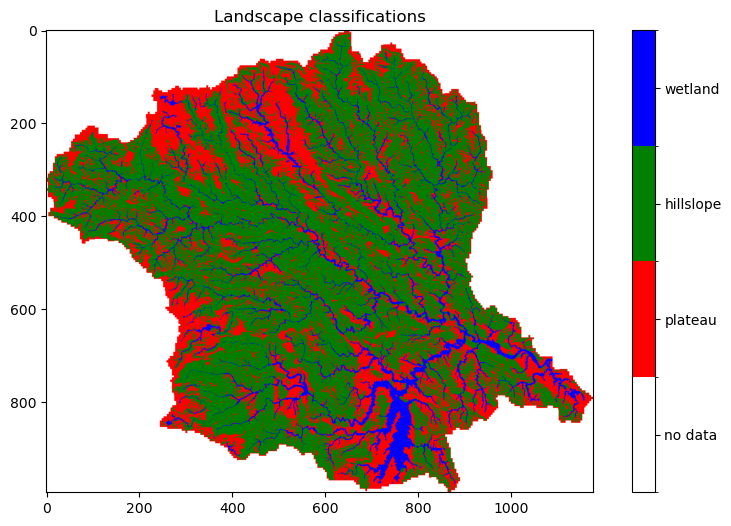

Hillslope percentage: 0.6040544567109684

Wetland percentage: 0.08657050074945284

Plateau percentage: 0.3092918540298783

In [12]:
'''UPDATE'''
# Make landscape classification
hillslope = np.array(slope) > 9
plateau = (np.array(hand) > 5) & (np.array(slope) <= 9)
wetland = (np.array(hand) <= 5) & (np.array(slope) <= 9)
basin = np.array(basin) > 0

'''UPDATE'''
hillslope_per = float(np.sum(hillslope))/float(np.sum(basin))
wetland_per = float(np.sum(wetland))/float(np.sum(basin))
plateau_per = float(np.sum(plateau))/float(np.sum(basin))

landscapes = np.zeros(DEM.shape)
landscapes[plateau] = 1
landscapes[hillslope] = 2
landscapes[wetland] = 3

# Plot landscapes
cmap = mpl.colors.ListedColormap(['white', 'red', 'green', 'blue'])
bounds = [0,1,2,3,4]
labels = ['no data', 'plateau', 'hillslope', 'wetland']
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, )

fig, ax = plt.subplots(figsize=(10,6))
ax.set_title('Landscape classifications')
im = ax.imshow(landscapes, cmap=cmap, norm=norm,)
# Create color bar
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5, 3.5])
cbar.set_ticklabels(labels)
plt.show()
landscape_per = np.array([plateau_per, hillslope_per, wetland_per])

print("Hillslope percentage:", hillslope_per)
print("Wetland percentage:", wetland_per)
print("Plateau percentage:", plateau_per)


## Loading forcing data 



In [13]:
path = Path.cwd()
forcing_path = path / "Forcing"

own_region = "manning"
shapeFile = forcing_path / f"{own_region}.shp"
grdc_station_is = '5202080'
saveLocation = forcing_path / f"{own_region}Forcing"

shape_area_manning = 6642 * 1e6 #m2

experiment_start_time  = "2014-01-01T00:00:00Z"
experiment_end_time    = "2024-12-31T00:00:00Z"

calibration_start_time = "2014-01-01T00:00:00Z"
calibration_end_time   = "2022-12-31T00:00:00Z"

validation_start_time  = "2023-01-01T00:00:00Z"
validation_end_time    = "2024-12-31T00:00:00Z"


In [14]:
ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
    dataset    = 'ERA5',
    start_time = experiment_start_time,
    end_time   = experiment_end_time,
    shape      = shapeFile.absolute(),
)

NameError: name 'ewatercycle' is not defined

In [3]:
#  load discharge......
df = pd.read_csv(
    './Data/5202080_Q_Day.Cmd.txt',
    delimiter=';',
    skiprows=36,
    header=0,
    encoding='cp1252'
)

df.columns = ["Date", "Time", "Discharge"]
df["Discharge"] = pd.to_numeric(df["Discharge"], errors="coerce")
df = df.dropna(subset=["Discharge"])
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df = df.set_index("Date")
df = df.drop(columns=["Time"])
df = df.sort_index()
#convert discahrge from m^3/s to mm/day
area_m2 = shape_area_manning
df["Discharge_mm_day"] = (df["Discharge"] * 86400) / area_m2) * 1000


SyntaxError: unmatched ')' (3325055421.py, line 19)

Load ERA5 forcing variables 

In [12]:
forcing_ds = xr.open_dataset(ERA5_forcing.directory / ERA5_forcing.filenames['pr'])
pr  = forcing_ds['pr'].values  * 86400   # kg/m²/s → mm/d
forcing_ds2 = xr.open_dataset(ERA5_forcing.directory / ERA5_forcing.filenames['evspsblpot'])
etp = forcing_ds2['evspsblpot'].values * 86400

dates = pd.date_range(experiment_start_time[:10], experiment_end_time[:10], freq='D')

forcing_df = pd.DataFrame({
    'Prec': pr.flatten()[:len(dates)],
    'Etp':  etp.flatten()[:len(dates)],
    'Qo': df["Discharge"].reindex(dates).values,
}, index=dates)

# Split into calibration and validation
df_cal = forcing_df[calibration_start_time[:10]:calibration_end_time[:10]]
df_val = forcing_df[validation_start_time[:10]:validation_end_time[:10]]

In [13]:
# ── Calibration / validation split with warm-up period ───────────────────────────────────────────
# df_cal_run: full forcing from 2000 — feeds the model including warm-up
# df_cal:     scoring window only, from 2002 onward
df_cal_run = forcing_df['2014-01-01' : calibration_end_time[:10]].copy()
df_cal     = forcing_df[calibration_start_time[:10] : calibration_end_time[:10]].copy()
df_val     = forcing_df[validation_start_time[:10]  : validation_end_time[:10]].copy()

n_warmup = len(forcing_df['2014-01-01':'2015-12-31'])

print(f'Warm-up run: {df_cal_run.index[0].date()} → {df_cal_run.index[-1].date()}  ({len(df_cal_run)} steps)')
print(f'Scoring cal: {df_cal.index[0].date()} → {df_cal.index[-1].date()}  ({len(df_cal)} steps)')
print(f'Validation:  {df_val.index[0].date()} → {df_val.index[-1].date()}  ({len(df_val)} steps)')
print(f'Warm-up steps skipped in scoring: {n_warmup}')

Warm-up run: 2014-01-01 → 2022-12-31  (3287 steps)

Scoring cal: 2014-01-01 → 2022-12-31  (3287 steps)

Validation:  2023-01-01 → 2024-12-31  (731 steps)

Warm-up steps skipped in scoring: 730

Basebline model run 

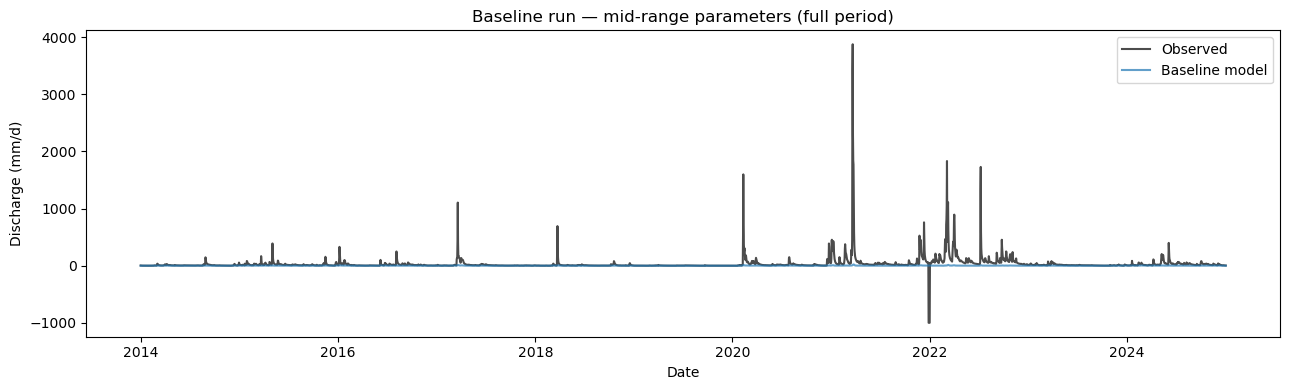

In [14]:
# ── Baseline run ──────────────────────────────────────────────────────────────
# labels_plateau   = ['Imax', 'Ce', 'Sumax', 'beta', 'Pmax', 'Kf']
# labels_hillslope = ['Imax', 'Ce', 'Sumax', 'beta', 'D',    'Kf']
# labels_wetland   = ['Imax', 'Ce', 'Sumax', 'beta', 'Cmax', 'Kf']
# labels_catchment = ['Ks', 'T_lag']

#I_max = 2-6.5 mm


p_min_plateau   = np.array([2,  0.2,  10,   0.5,  0.1,   0.1])
p_max_plateau   = np.array([6.5,   2.0,  200,  3.0,  5.0,   0.99])
p_min_hillslope = np.array([2,  0.2,  50,   0.5,  0.01,  0.1])
p_max_hillslope = np.array([6.5,   2.0,  400,  3.0,  0.99,  0.99])
p_min_wetland   = np.array([2,  0.2,  20,   0.5,  0.01,  0.1])
p_max_wetland   = np.array([6.5,   2.0,  200,  3.0,  2.0,   0.99])
p_min_catch = np.array([0.001,  1.0])
p_max_catch = np.array([0.2,   10.0])

par0_plateau   = (p_min_plateau   + p_max_plateau)   / 2
par0_hillslope = (p_min_hillslope + p_max_hillslope) / 2
par0_wetland   = (p_min_wetland   + p_max_wetland)   / 2
par0_catch     = (p_min_catch     + p_max_catch)     / 2

Qm_baseline = FLEXtopo(par0_plateau, par0_hillslope, par0_wetland,
                        par0_catch, forcing_df, landscape_per)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(forcing_df.index, forcing_df['Qo'], label='Observed',       alpha=0.7, color='black')
ax.plot(forcing_df.index, Qm_baseline,     label='Baseline model', alpha=0.7)
ax.set_title('Baseline run — mid-range parameters (full period)')
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (mm/d)')
ax.legend()
plt.tight_layout()
plt.show()

Objective Functions

In [15]:
def mae_objective(Qm, Qo):
    """Mean Absolute Error. Lower is better."""
    n = min(len(Qm), len(Qo))
    return np.mean(np.abs(Qo[:n] - Qm[:n]))


def nse_objective(Qm, Qo):
    """
    Nash-Sutcliffe Efficiency and log-NSE. Higher is better.
    Returns (NSE, log-NSE).
    """
    n = min(len(Qm), len(Qo))
    sim, obs = Qm[:n], Qo[:n]

    valid    = ~np.isnan(obs) & ~np.isnan(sim)
    sim, obs = sim[valid], obs[valid]
    obs_mean = np.mean(obs)

    nse = 1.0 - np.sum((obs - sim)**2) / np.sum((obs - obs_mean)**2)

    # FIX: clip to epsilon before log to handle zeros and tiny negatives
    eps     = 1e-6
    log_obs = np.log(np.maximum(obs, eps))
    log_sim = np.log(np.maximum(sim, eps))
    log_nse = 1.0 - np.sum((log_obs - log_sim)**2) / np.sum((log_obs - np.mean(log_obs))**2)

    return nse, log_nse

Calibration

In [16]:
def run_flextopo_flat(flat_params, forcing_df, landscape_per):

    ParPlateau   = flat_params[0:6]
    ParHillslope = flat_params[6:12]
    ParWetland   = flat_params[12:18]
    ParCatchment = flat_params[18:20]
    return FLEXtopo(ParPlateau, ParHillslope, ParWetland,
                    ParCatchment, forcing_df, landscape_per)

# ── Build flat bounds ────────────────────────────────────────────────────────
p_min_flat = np.concatenate([p_min_plateau, p_min_hillslope, p_min_wetland, p_min_catch])
p_max_flat = np.concatenate([p_max_plateau, p_max_hillslope, p_max_wetland, p_max_catch])

N   = 1000     # number of random samples — increase for a more thorough search
rng = np.random.default_rng(seed=42)
parameter_ensemble = rng.uniform(low=p_min_flat, high=p_max_flat, size=(N, 20))

print(f'Sampling {N} parameter sets, each with {parameter_ensemble.shape[1]} parameters')

Sampling 1000 parameter sets, each with 20 parameters

In [17]:
# ── Run ensemble on calibration period ──────────────────────────────────────
Q_cal = df_cal['Qo'].values

mae_scores = []
nse_scores = []

for i, flat_p in enumerate(parameter_ensemble):
    Qm_full = run_flextopo_flat(flat_p, df_cal_run, landscape_per)
    Qm      = Qm_full[n_warmup:]   # ← skip warm-up, align with Q_cal
    mae_scores.append(mae_objective(Qm, Q_cal))
    nse_scores.append(nse_objective(Qm, Q_cal))

mae_scores     = np.array(mae_scores)
nse_values     = np.array([s[0] for s in nse_scores])
log_nse_values = np.array([s[1] for s in nse_scores])

print('Done.')
print(f'Best MAE:     {np.min(mae_scores):.4f}  (member {np.argmin(mae_scores)})')
print(f'Best NSE:     {np.max(nse_values):.4f}  (member {np.argmax(nse_values)})')
print(f'Best log-NSE: {np.max(log_nse_values):.4f}  (member {np.argmax(log_nse_values)})')

Done.

Best MAE:     15.6054  (member 680)

Best NSE:     -0.0736  (member 785)

Best log-NSE: -0.4652  (member 680)

Calibration Results 

In [ ]:
# Parameter labels for each unit
labels_plateau   = ['Imax', 'Ce', 'Sumax', 'beta', 'Pmax', 'Kf']
labels_hillslope = ['Imax', 'Ce', 'Sumax', 'beta', 'D',    'Kf']
labels_wetland   = ['Imax', 'Ce', 'Sumax', 'beta', 'Cmax', 'Kf']
labels_catchment = ['Ks', 'T_lag']

all_labels = (
    [f'Plateau — {l}'   for l in labels_plateau]   +
    [f'Hillslope — {l}' for l in labels_hillslope] +
    [f'Wetland — {l}'   for l in labels_wetland]   +
    [f'Catchment — {l}' for l in labels_catchment]
)

def dotty_plots(scores, title, ylabel, best_fn):
    n_params = parameter_ensemble.shape[1]
    ncols = 5
    nrows = -(-n_params // ncols)   # ceiling division
    fig, axs = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
    fig.suptitle(title, fontsize=14)
    axs = axs.flatten()
    best_idx = best_fn(scores)
    for j in range(n_params):
        axs[j].scatter(parameter_ensemble[:, j], scores, s=10, alpha=0.6, color='steelblue')
        axs[j].scatter(parameter_ensemble[best_idx, j], scores[best_idx],
                       s=60, color='red', zorder=5, label='Best')
        axs[j].set_title(all_labels[j], fontsize=8)
        axs[j].set_xlabel('Value', fontsize=7)
        axs[j].set_ylabel(ylabel, fontsize=7)
    for j in range(n_params, len(axs)):
        axs[j].set_visible(False)
    plt.tight_layout()
    plt.show()

dotty_plots(mae_scores,   'Calibration — MAE (lower = better)',    'MAE',     np.argmin)
dotty_plots(nse_values,   'Calibration — NSE (higher = better)',   'NSE',     np.argmax)
dotty_plots(log_nse_values, 'Calibration — log-NSE (higher = better)', 'log-NSE', np.argmax)

In [ ]:
# ── Best parameter sets ──────────────────────────────────────────────────────
best_idx_mae     = np.argmin(mae_scores)
best_idx_nse     = np.argmax(nse_values)
best_idx_lognse  = np.argmax(log_nse_values)

best_params_mae    = parameter_ensemble[best_idx_mae]
best_params_nse    = parameter_ensemble[best_idx_nse]
best_params_lognse = parameter_ensemble[best_idx_lognse]

def print_params(flat_p, label):
    print(f'\n{label}')
    print(f'  Plateau:    {dict(zip(labels_plateau,   flat_p[0:6].round(4)))}')
    print(f'  Hillslope:  {dict(zip(labels_hillslope, flat_p[6:12].round(4)))}')
    print(f'  Wetland:    {dict(zip(labels_wetland,   flat_p[12:18].round(4)))}')
    print(f'  Catchment:  {dict(zip(labels_catchment, flat_p[18:20].round(4)))}')

print_params(best_params_mae,    f'Best MAE     = {mae_scores[best_idx_mae]:.4f}')
print_params(best_params_nse,    f'Best NSE     = {nse_values[best_idx_nse]:.4f}')
print_params(best_params_lognse, f'Best log-NSE = {log_nse_values[best_idx_lognse]:.4f}')

In [ ]:
#validation
Qo_val = df_val['Q'].values

results = {}
for label, flat_p in [('MAE', best_params_mae),
                       ('NSE', best_params_nse),
                       ('log-NSE', best_params_lognse)]:
    Qm_val = run_flextopo_flat(flat_p, df_val, landscape_per)
    nse_v, lognse_v = nse_objective(Qm_val, Qo_val)
    mae_v           = mae_objective(Qm_val, Qo_val)
    results[label]  = {'Qm': Qm_val, 'MAE': mae_v, 'NSE': nse_v, 'log-NSE': lognse_v}
    print(f'Calibrated on {label:8s} → validation MAE={mae_v:.4f}  NSE={nse_v:.4f}  log-NSE={lognse_v:.4f}')

In [ ]:
#visualize results 
# ── Calibration period ───────────────────────────────────────────────────────
Qo_cal    = df_cal['Q'].values
cal_dates = df_cal.index  # date is the index, not a column

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for ax, (label, flat_p) in zip(axes, [('MAE',     best_params_mae),
                                        ('NSE',     best_params_nse),
                                        ('log-NSE', best_params_lognse)]):
    Qm_c = run_flextopo_flat(flat_p, df_cal, landscape_per)
    ax.plot(cal_dates, Qo_cal, label='Observed',               color='black', lw=1.2)
    ax.plot(cal_dates, Qm_c,   label=f'Modelled (best {label})', lw=1)
    ax.set_title(f'Calibration — best {label} '
                 f'(NSE={results[label]["NSE"]:.3f} on validation)')
    ax.set_ylabel('Discharge (mm/d)')
    ax.legend(fontsize=8)
axes[-1].set_xlabel('Date')
fig.suptitle('FLEXtopo — Calibration period', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Validation period ────────────────────────────────────────────────────────
val_dates = df_val.index  # date is the index, not a column

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for ax, (label, res) in zip(axes, results.items()):
    ax.plot(val_dates, Qo_val,    label='Observed',               color='black', lw=1.2)
    ax.plot(val_dates, res['Qm'], label=f'Modelled (best {label})', lw=1)
    ax.set_title(f'Validation — best {label}  '
                 f'(MAE={res["MAE"]:.4f}  NSE={res["NSE"]:.4f}  log-NSE={res["log-NSE"]:.4f})')
    ax.set_ylabel('Discharge (mm/d)')
    ax.legend(fontsize=8)
axes[-1].set_xlabel('Date')
fig.suptitle('FLEXtopo — Validation period', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Full-period overview with best NSE parameters ────────────────────────────
Qm_full = run_flextopo_flat(best_params_nse, forcing_df, landscape_per)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(forcing_df.index, forcing_df['Q'], label='Observed',            color='black', lw=1)
ax.plot(forcing_df.index, Qm_full,         label='Modelled (best NSE)', lw=1, alpha=0.8)
ax.axvline(pd.Timestamp(validation_start_time[:10]),
           color='grey', linestyle='--', label='Cal / Val split')
ax.set_title('FLEXtopo — full period (best NSE parameters)')
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (mm/d)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION: Model Validity Checks
#   1. Water balance residuals
#   2. Budyko framework
# ════════════════════════════════════════════════════════════════════════════

# ── Extended FLEXtopo that also returns states and ET ────────────────────────
# Needed to compute S[t] for the residual check

def FLEXtopo_diagnostic(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscapes):
    """Same as FLEXtopo but also returns total storage S and total ET per timestep."""
    T_lag = ParCatchment[1]
    Ks    = ParCatchment[0]
    dt    = 1
    t_max = len(forcing['Q'])

    States_plateau   = np.zeros((t_max, 3))
    States_hillslope = np.zeros((t_max, 3))
    States_wetland   = np.zeros((t_max, 3))
    Ss = np.zeros(t_max)

    Fluxes_plateau   = np.zeros((t_max, 4))
    Fluxes_hillslope = np.zeros((t_max, 4))
    Fluxes_wetland   = np.zeros((t_max, 3))
    Qs_dt    = np.zeros(t_max)
    Q_tot_dt = np.zeros(t_max)

    for t in range(t_max):
        Fluxes_plateau,   States_plateau   = plateau_func(
            t, ParPlateau,   forcing, Fluxes_plateau,   States_plateau)
        Fluxes_hillslope, States_hillslope = hillslope_func(
            t, ParHillslope, forcing, Fluxes_hillslope, States_hillslope)
        Fluxes_wetland,   States_wetland, Ss = wetland_func(
            t, ParWetland,   forcing, Fluxes_wetland,   States_wetland, Ss, landscapes[2])

        Ss[t] = (Ss[t]
                 + Fluxes_plateau[t, 3]   * landscapes[0]
                 + Fluxes_hillslope[t, 3] * landscapes[1])

        Qs_dt[t] = dt * Ks * Ss[t]
        Ss[t]    = Ss[t] - min(Qs_dt[t], Ss[t])
        if t < t_max - 1:
            Ss[t+1] = Ss[t]

        Q_tot_dt[t] = (Qs_dt[t]
                       + Fluxes_plateau[t, 2]   * landscapes[0]
                       + Fluxes_hillslope[t, 2] * landscapes[1]
                       + Fluxes_wetland[t, 2]   * landscapes[2])

    weights = Weigfun(T_lag)
    Qm = np.convolve(Q_tot_dt, weights)[:t_max]

    # Total storage per timestep: sum all reservoir states weighted by landscape fraction
    S = (  (States_plateau[:,0]   + States_plateau[:,1]   + States_plateau[:,2])   * landscapes[0]
         + (States_hillslope[:,0] + States_hillslope[:,1] + States_hillslope[:,2]) * landscapes[1]
         + (States_wetland[:,0]   + States_wetland[:,1]   + States_wetland[:,2])   * landscapes[2]
         + Ss)

    # Total ET per timestep (interception + transpiration, weighted by landscape fraction)
    ET = (  (Fluxes_plateau[:,0]   + Fluxes_plateau[:,1])   * landscapes[0]
          + (Fluxes_hillslope[:,0] + Fluxes_hillslope[:,1]) * landscapes[1]
          + (Fluxes_wetland[:,0]   + Fluxes_wetland[:,1])   * landscapes[2])

    return Qm, S, ET


# Run diagnostic version on the calibration run window (with warm-up)
ParPlateau   = best_params_nse[0:6]
ParHillslope = best_params_nse[6:12]
ParWetland   = best_params_nse[12:18]
ParCatchment = best_params_nse[18:20]

Qm_diag, S_diag, ET_diag = FLEXtopo_diagnostic(
    ParPlateau, ParHillslope, ParWetland, ParCatchment, df_cal_run, landscape_per)

# Trim to scoring window (skip warm-up)
Qm  = Qm_diag[n_warmup:]
S   = S_diag[n_warmup:]
ET  = ET_diag[n_warmup:]
P   = df_cal['Prec'].values
Q   = df_cal['Q'].values


# ── WATER BALANCE CHECK — annual and multi-year ──────────────────────────────
# Over a full hydrological year: P = Q + AET + ΔS
# Residual = P - Q - AET - ΔS  (should be ~0 if model is mass-conservative)
# ΔS = S[end of year] - S[start of year]

# Run diagnostic to get S and ET over calibration period
Qm_diag, S_diag, ET_diag = FLEXtopo_diagnostic(
    ParPlateau, ParHillslope, ParWetland, ParCatchment, df_cal_run, landscape_per)

# Trim to scoring window
Qm  = Qm_diag[n_warmup:]
S   = S_diag[n_warmup:]
ET  = ET_diag[n_warmup:]
P   = df_cal['Prec'].values
Q   = df_cal['Q'].values

# Build annual sums, plus S at start and end of each year for ΔS
df_annual = pd.DataFrame({
    'P':   P,
    'Q':   Q,
    'Qm':  Qm,
    'ET':  ET,
    'S':   S,
}, index=df_cal.index)

# Annual sums of fluxes
annual = df_annual[['P', 'Q', 'Qm', 'ET']].resample('YE').sum()

# ΔS = last S of the year minus first S of the year
annual['S_start'] = df_annual['S'].resample('YE').first()
annual['S_end']   = df_annual['S'].resample('YE').last()
annual['dS']      = annual['S_end'] - annual['S_start']

# Residual per year: P - Q_modelled - AET - ΔS
annual['residual'] = annual['P'] - annual['Qm'] - annual['ET'] - annual['dS']

print("=== Annual Water Balance ===")
print(annual[['P', 'Qm', 'ET', 'dS', 'residual']].round(2).to_string())
print(f"\nMean annual residual:      {annual['residual'].mean():.3f} mm/yr")
print(f"Max annual residual:       {annual['residual'].abs().max():.3f} mm/yr")
print(f"Residual as % of mean P:   {100 * annual['residual'].mean() / annual['P'].mean():.2f} %")

# Multi-year residual: ΔS over the whole period averages out
dS_total    = S[-1] - S[0]
residual_multiyear = P.sum() - Qm.sum() - ET.sum() - dS_total
print(f"\n=== Multi-year Water Balance ===")
print(f"Total P:                   {P.sum():.1f} mm")
print(f"Total Qm:                  {Qm.sum():.1f} mm")
print(f"Total ET:                  {ET.sum():.1f} mm")
print(f"Total ΔS (S_end - S_start): {dS_total:.1f} mm")
print(f"Multi-year residual:       {residual_multiyear:.3f} mm")
print(f"Residual as % of total P:  {100 * residual_multiyear / P.sum():.2f} %")


# ── 2. BUDYKO FRAMEWORK ──────────────────────────────────────────────────────
# Annual means for observed and modelled

df_budyko = pd.DataFrame({
    'P':   P,
    'Q':   Q,
    'Qm':  Qm,
    'PET': df_cal['Etp'].values,
    'ET':  ET
}, index=df_cal.index).resample('YE').sum()

phi_obs  = df_budyko['PET'] / df_budyko['P']          # aridity index (same P and PET for obs/mod)
EAP_obs  = (df_budyko['P'] - df_budyko['Q'])  / df_budyko['P']   # observed  AET/P
EAP_mod  = df_budyko['ET'] / df_budyko['P']                       # modelled  AET/P

# Budyko curve + limits
phi_curve  = np.linspace(0.01, 5, 200)
EAP_budyko = np.sqrt(phi_curve * np.tanh(1 / phi_curve) * (1 - np.exp(-phi_curve)))
energy_limit = phi_curve
water_limit  = np.ones_like(phi_curve)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(phi_curve, EAP_budyko,   'k-',  lw=2,   label='Budyko curve')
ax.plot(phi_curve, energy_limit, 'k--', lw=0.8, label='Energy limit (AET = PET)')
ax.plot(phi_curve, water_limit,  'k:',  lw=0.8, label='Water limit (AET = P)')

ax.scatter(phi_obs, EAP_obs, color='black',     s=50, zorder=5, label='Observed (annual)')
ax.scatter(phi_obs, EAP_mod, color='steelblue', s=50, zorder=5, marker='^',
           label='Modelled (annual)')

for yr, x, y in zip(df_budyko.index.year, phi_obs, EAP_obs):
    ax.annotate(str(yr), (x, y), textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.set_xlim(0, 3)
ax.set_ylim(0, 1.2)
ax.set_xlabel('Aridity index  φ = PET / P')
ax.set_ylabel('Evaporative index  AET / P')
ax.set_title('Budyko Framework — Observed vs Modelled')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [286]:
# #  discharge
# df = pd.read_csv(
#     './Data/5202080_Q_Day.Cmd.txt',
#     delimiter=';',
#     skiprows=36,
#     header=0,
#     encoding='cp1252'
# )

# df.columns = ["Date", "Time", "Discharge"]
# df["Discharge"] = pd.to_numeric(df["Discharge"], errors="coerce")
# df = df.dropna(subset=["Discharge"])
# df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
# df = df.set_index("Date")
# df = df.drop(columns=["Time"])
# df = df.sort_index()

# #precipitation
# precip = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
# precip["Date"] = pd.to_datetime(precip["system:index"], format="%Y%m%d")
# precip = precip.set_index("Date")[["total_precipitation_sum"]]
# precip = precip.rename(columns={"total_precipitation_sum": "pr"})
# precip["pr"] = precip["pr"] * 1000   # m/day → mm/day

# # evaporation 
# evap = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
# evap["Date"] = pd.to_datetime(evap["system:index"], format="%Y%m%d")
# evap = evap.set_index("Date")[["total_evaporation_sum"]]
# evap = evap.rename(columns={"total_evaporation_sum": "evspsblpot"})
# evap["evspsblpot"] = evap["evspsblpot"].abs() * 1000   # m/day → mm/day

# #forcing_df
# forcing_df = precip.join(evap, how="inner")
# forcing_df = forcing_df.rename(columns={
#     "pr": "Prec",
#     "evspsblpot": "Etp"
# })
# forcing_df["Qo"] = df["Discharge"]
# forcing_df.index = forcing_df.index.normalize()
# forcing_df = forcing_df.sort_index()

# # calibration and validation
# df_cal = forcing_df.loc["2014-01-01":"2022-12-31"]
# df_val = forcing_df.loc["2023-01-01":"2024-12-31"]


In [288]:
#  Warm-up period ---
df_warmup = forcing_df.loc["2014-01-01":"2016-12-31"]

# Calibration
df_cal = forcing_df.loc["2014-01-01":"2022-12-31"]

#warm-up + calibration
df_run = forcing_df.loc["2014-01-01":"2022-12-31"]

#
Qm_full = run_flextopo_flat(param_vector, df_run[["Prec", "Etp", "Qo"]], landscape_per)
Qm_cal = Qm_full[len(df_warmup):]


In [289]:

from ewatercycle_wrapper_HBV import HBV

forcing = {
    "directory": "Forcing",
    "start_time": forcing_df.index.min().strftime("%Y-%m-%dT00:00:00Z"),
    "end_time": forcing_df.index.max().strftime("%Y-%m-%dT00:00:00Z"),
    "pr": "manning_hbv_forcing_custom.nc",
    "evspsblpot": "manning_hbv_forcing_custom.nc",
}

model = HBV(forcing=forcing)


Test parameters

Plateau   : [ 3.75   0.8   90.     1.4    1.1    0.225]

Hillslope : [3.75e+00 8.00e-01 3.00e+02 1.40e+00 3.25e-01 2.75e-01]

Wetland   : [  4.      0.8   105.      1.4     0.425   0.165]

Catchment : [0.0255 3.    ]

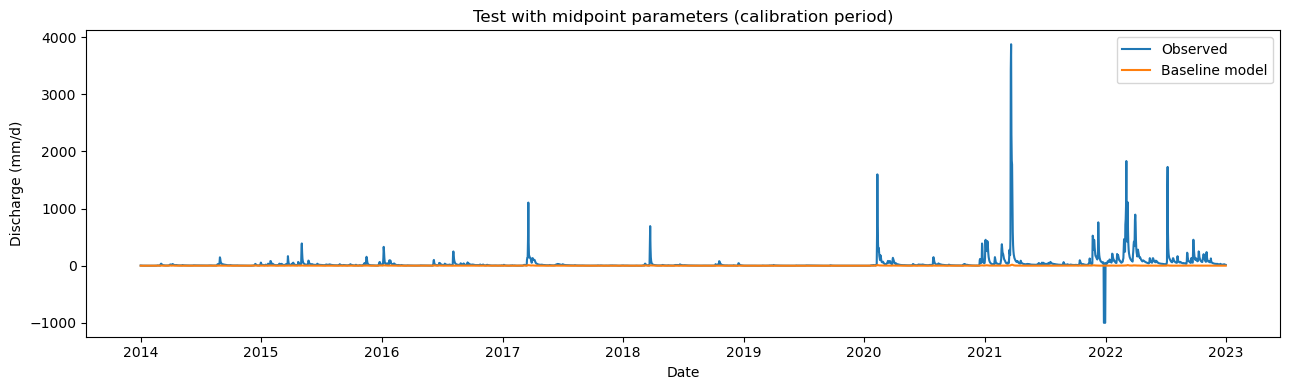

In [290]:
# Parameter bounds
p_min_plateau   = np.array([2.0, 0.4,  30.0, 0.8, 0.2, 0.05])
p_max_plateau   = np.array([5.5, 1.2, 150.0, 2.0, 2.0, 0.40])

p_min_hillslope = np.array([2.0, 0.4, 100.0, 0.8, 0.05, 0.05])
p_max_hillslope = np.array([5.5, 1.2, 500.0, 2.0, 0.60, 0.50])

p_min_wetland   = np.array([2.0, 0.4,  30.0, 0.8, 0.05, 0.03])
p_max_wetland   = np.array([6.0, 1.2, 180.0, 2.0, 0.80, 0.30])

p_min_catch     = np.array([0.001, 1.0])
p_max_catch     = np.array([0.05,  5.0])

# Midpoints
par_plateau   = (p_min_plateau   + p_max_plateau) / 2
par_hillslope = (p_min_hillslope + p_max_hillslope) / 2
par_wetland   = (p_min_wetland   + p_max_wetland) / 2
par_catch     = (p_min_catch     + p_max_catch) / 2

# FLEXtopo forcing subset
forcing_df_flex = forcing_df[["Prec", "Etp", "Qo"]]

# Baseline run
Qm_baseline = FLEXtopo(
    par_plateau,
    par_hillslope,
    par_wetland,
    par_catch,
    forcing_df_flex.loc[df_cal.index],
    landscape_per
)

Qo_baseline = df_cal["Qo"].values

print("Test parameters")
print("Plateau   :", par_plateau)
print("Hillslope :", par_hillslope)
print("Wetland   :", par_wetland)
print("Catchment :", par_catch)

# Plot
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_cal.index, df_cal["Qo"], label="Observed")
ax.plot(df_cal.index, Qm_baseline, label="Baseline model")
ax.set_title("Test with midpoint parameters (calibration period)")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (mm/d)")
ax.legend()
plt.tight_layout()
plt.show()


In [291]:
def mae_objective(Qm, Qo): #mean ablolute errorrr, lower better
    Qm = np.asarray(Qm, dtype=float)
    Qo = np.asarray(Qo, dtype=float)
    n = min(len(Qm), len(Qo))
    sim = Qm[:n]
    obs = Qo[:n]
    valid = ~np.isnan(obs) & ~np.isnan(sim)
    sim = sim[valid]
    obs = obs[valid]
    if len(obs) == 0:
        return np.nan
    return np.mean(np.abs(obs - sim))
    
def nse_objective(Qm, Qo):   #Nash-Sutcliffe Efficiency and log-NSE
    Qm = np.asarray(Qm, dtype=float)
    Qo = np.asarray(Qo, dtype=float)

    n = min(len(Qm), len(Qo))
    sim = Qm[:n]
    obs = Qo[:n]

    valid = ~np.isnan(obs) & ~np.isnan(sim)
    sim = sim[valid]
    obs = obs[valid]

    if len(obs) == 0:
        return np.nan, np.nan

    obs_mean = np.mean(obs)
    denom = np.sum((obs - obs_mean) ** 2)

    if denom == 0:
        nse = np.nan
    else:
        nse = 1.0 - np.sum((obs - sim) ** 2) / denom

    eps = 1e-6
    log_obs = np.log(np.maximum(obs, eps))
    log_sim = np.log(np.maximum(sim, eps))

    log_denom = np.sum((log_obs - np.mean(log_obs)) ** 2)
    if log_denom == 0:
        log_nse = np.nan
    else:
        log_nse = 1.0 - np.sum((log_obs - log_sim) ** 2) / log_denom

    return nse, log_nse

## Run Model

We loaded our data above and saved it as forcing. The parameters are defined before for with the HBV model, now we  need to define them for Plateau, Hillslope and Wetland areas. Ks and T_lag are defined for the whole catchment.

In [292]:
## Calibration for finding parameters
def run_flextopo_flat(param_vector, forcing_df, landscape_per):
    ParPlateau   = np.array(param_vector[0:6])
    ParHillslope = np.array(param_vector[6:12])
    ParWetland   = np.array(param_vector[12:18])
    ParCatchment = np.array(param_vector[18:20])

    return FLEXtopo(
        ParPlateau,
        ParHillslope,
        ParWetland,
        ParCatchment,
        forcing_df,
        landscape_per
    )

p_min_plateau   = np.array([2.0, 0.4,  30.0, 0.8, 0.2, 0.05])
p_max_plateau   = np.array([5.5, 1.2, 150.0, 2.0, 2.0, 0.40])

p_min_hillslope = np.array([2.0, 0.4, 100.0, 0.8, 0.05, 0.05])
p_max_hillslope = np.array([5.5, 1.2, 500.0, 2.0, 0.60, 0.50])

p_min_wetland   = np.array([2.0, 0.4,  30.0, 0.8, 0.05, 0.03])
p_max_wetland   = np.array([6.0, 1.2, 180.0, 2.0, 0.80, 0.30])

p_min_catch     = np.array([0.001, 1.0])
p_max_catch     = np.array([0.05,  5.0])

p_min_flat = np.concatenate([p_min_plateau, p_min_hillslope, p_min_wetland, p_min_catch])
p_max_flat = np.concatenate([p_max_plateau, p_max_hillslope, p_max_wetland, p_max_catch])
Qo_cal = df_cal["Qo"].values
N = 500
rng = np.random.default_rng(seed=42)

parameter_ensemble = rng.uniform(
    low=p_min_flat,
    high=p_max_flat,
    size=(N, 20)
)

print(f"Sampling {N} parameter sets, each with {parameter_ensemble.shape[1]} parameters")

Qo_cal = df_cal["Qo"].values

best_nse = -np.inf
best_log_nse = np.nan
best_mae = np.nan
best_param_vector = None
best_Qm = None

for i in range(N):
    param_vector = rng.uniform(low=p_min_flat, high=p_max_flat, size=20)

    try:
        # run inclusief warm-up
        Qm_full = run_flextopo_flat(param_vector, df_cal_run, landscape_per)

        # warm-up afknippen zodat model en observaties exact dezelfde periode hebben
        Qm_cal = np.asarray(Qm_full[n_warmup:], dtype=float)

        # extra veiligheidscheck
        n = min(len(Qm_cal), len(Qo_cal))
        Qm_cal = Qm_cal[:n]
        Qo_use = Qo_cal[:n]

        mae = mae_objective(Qm_cal, Qo_use)
        nse, log_nse = nse_objective(Qm_cal, Qo_use)

        if np.isfinite(nse) and nse > best_nse:
            best_nse = nse
            best_log_nse = log_nse
            best_mae = mae
            best_param_vector = param_vector.copy()
            best_Qm = Qm_cal.copy()

    except Exception:
        continue
print("Best run found")
print(f"NSE    : {best_nse:.3f}")
print(f"logNSE : {best_log_nse:.3f}")
print(f"MAE    : {best_mae:.3f}")

ParPlateau_best   = best_param_vector[0:6]
ParHillslope_best = best_param_vector[6:12]
ParWetland_best   = best_param_vector[12:18]
ParCatchment_best = best_param_vector[18:20]



Sampling 500 parameter sets, each with 20 parameters

Best run found

NSE    : -0.275

logNSE : -2.546

MAE    : 13.837

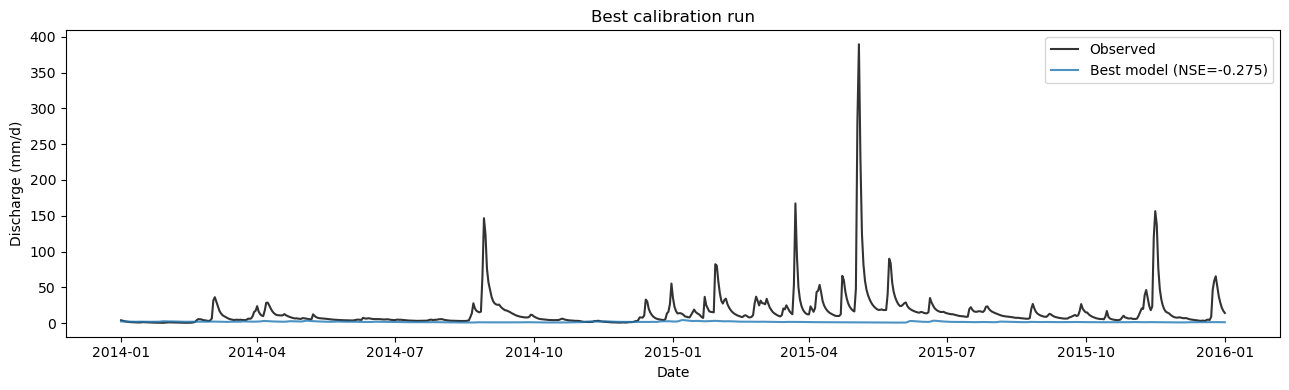

In [293]:
n_plot = min(len(df_cal), len(best_Qm))

plt.figure(figsize=(13, 4))
plt.plot(df_cal.index[:n_plot], df_cal["Qo"].values[:n_plot], label="Observed", color="black", alpha=0.8)
plt.plot(df_cal.index[:n_plot], best_Qm[:n_plot], label=f"Best model (NSE={best_nse:.3f})", alpha=0.8)

plt.title("Best calibration run")
plt.xlabel("Date")
plt.ylabel("Discharge (mm/d)")
plt.legend()
plt.tight_layout()
plt.show()

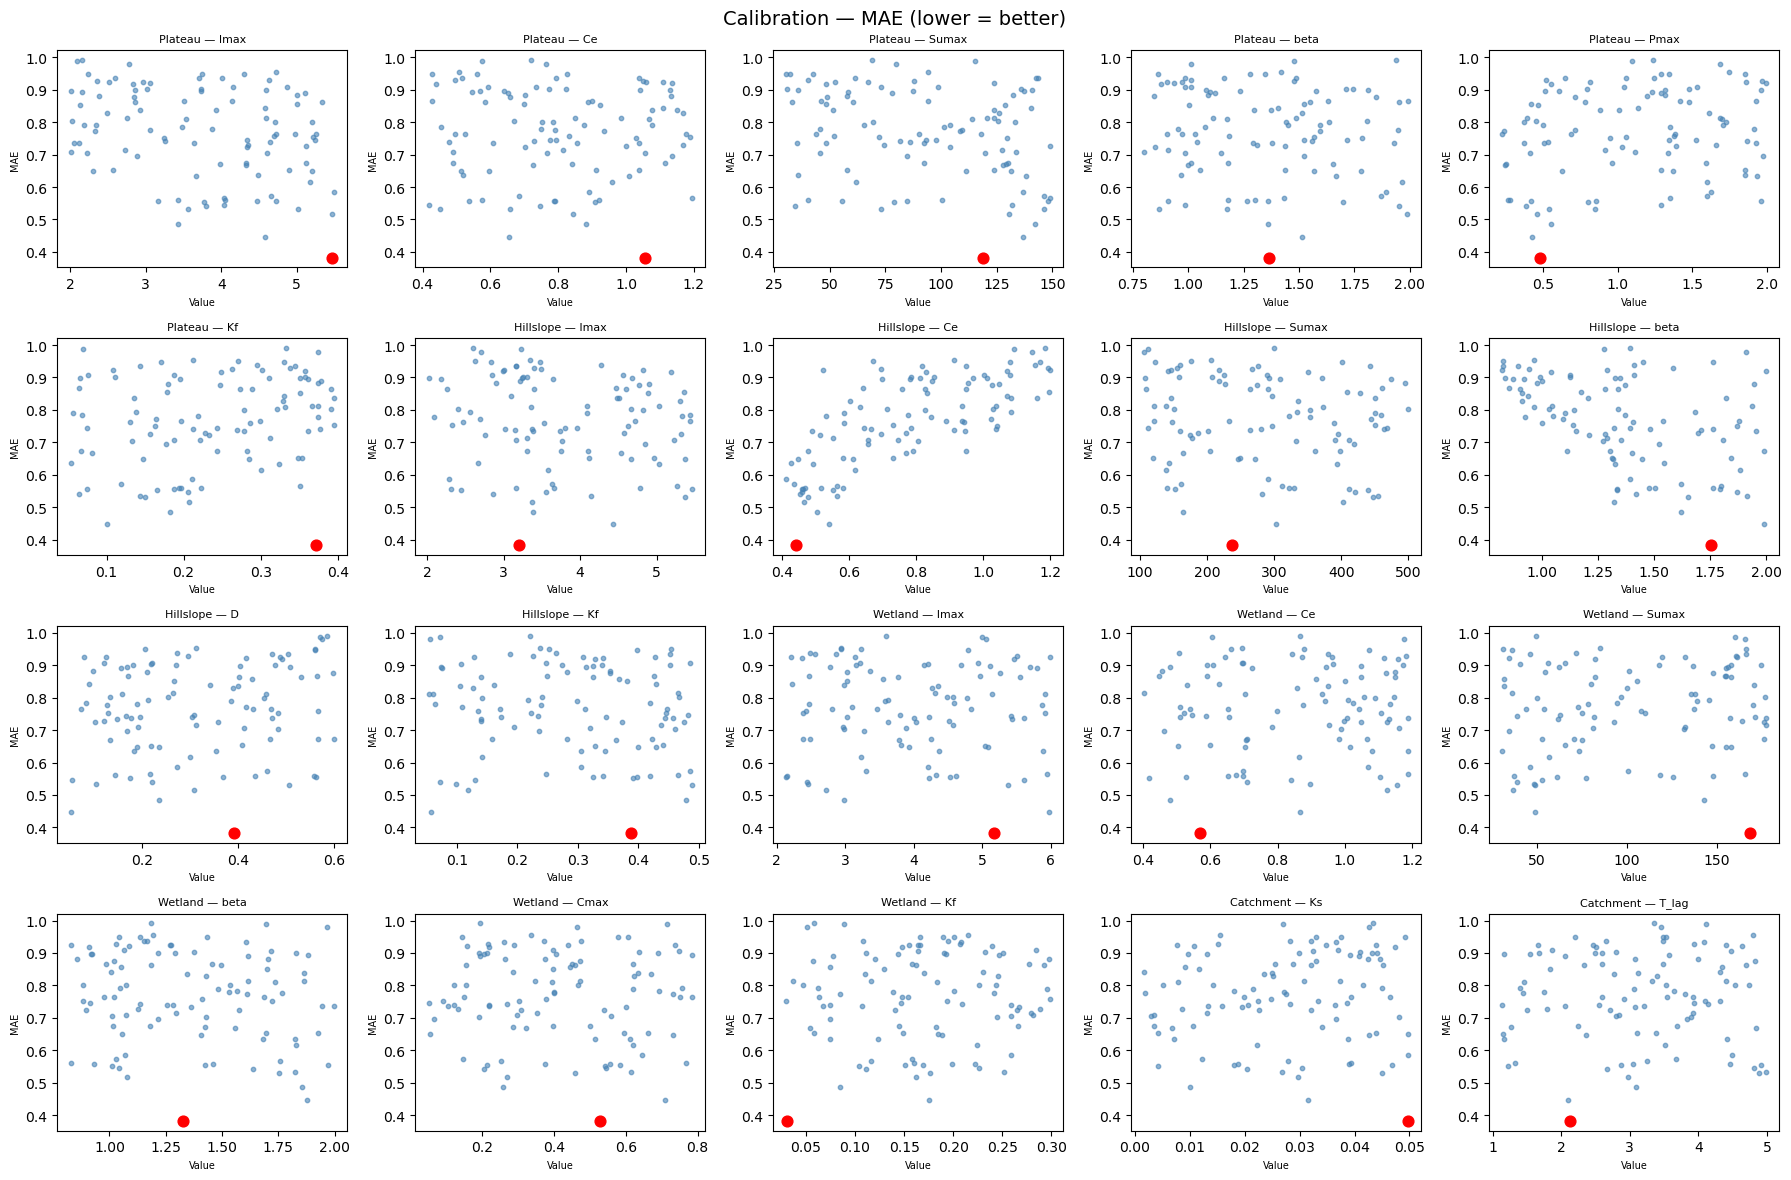

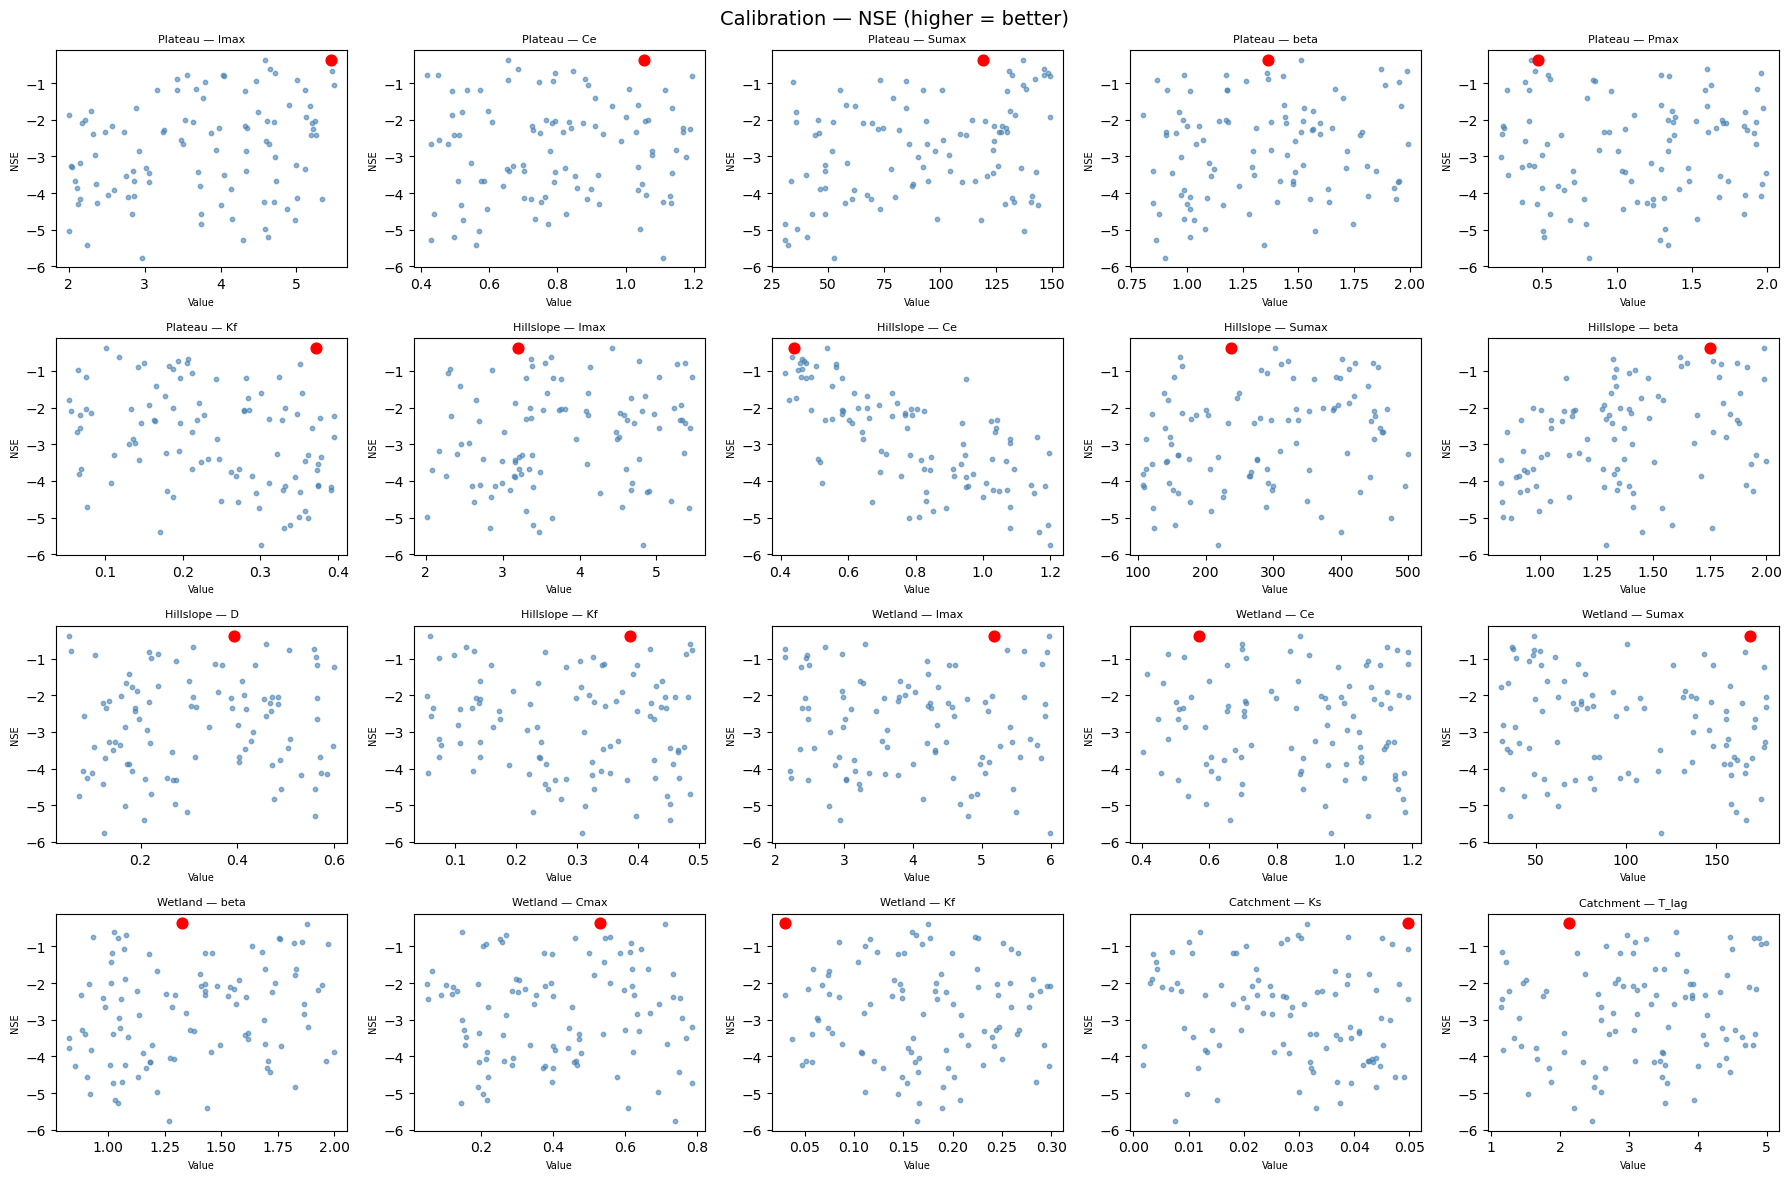

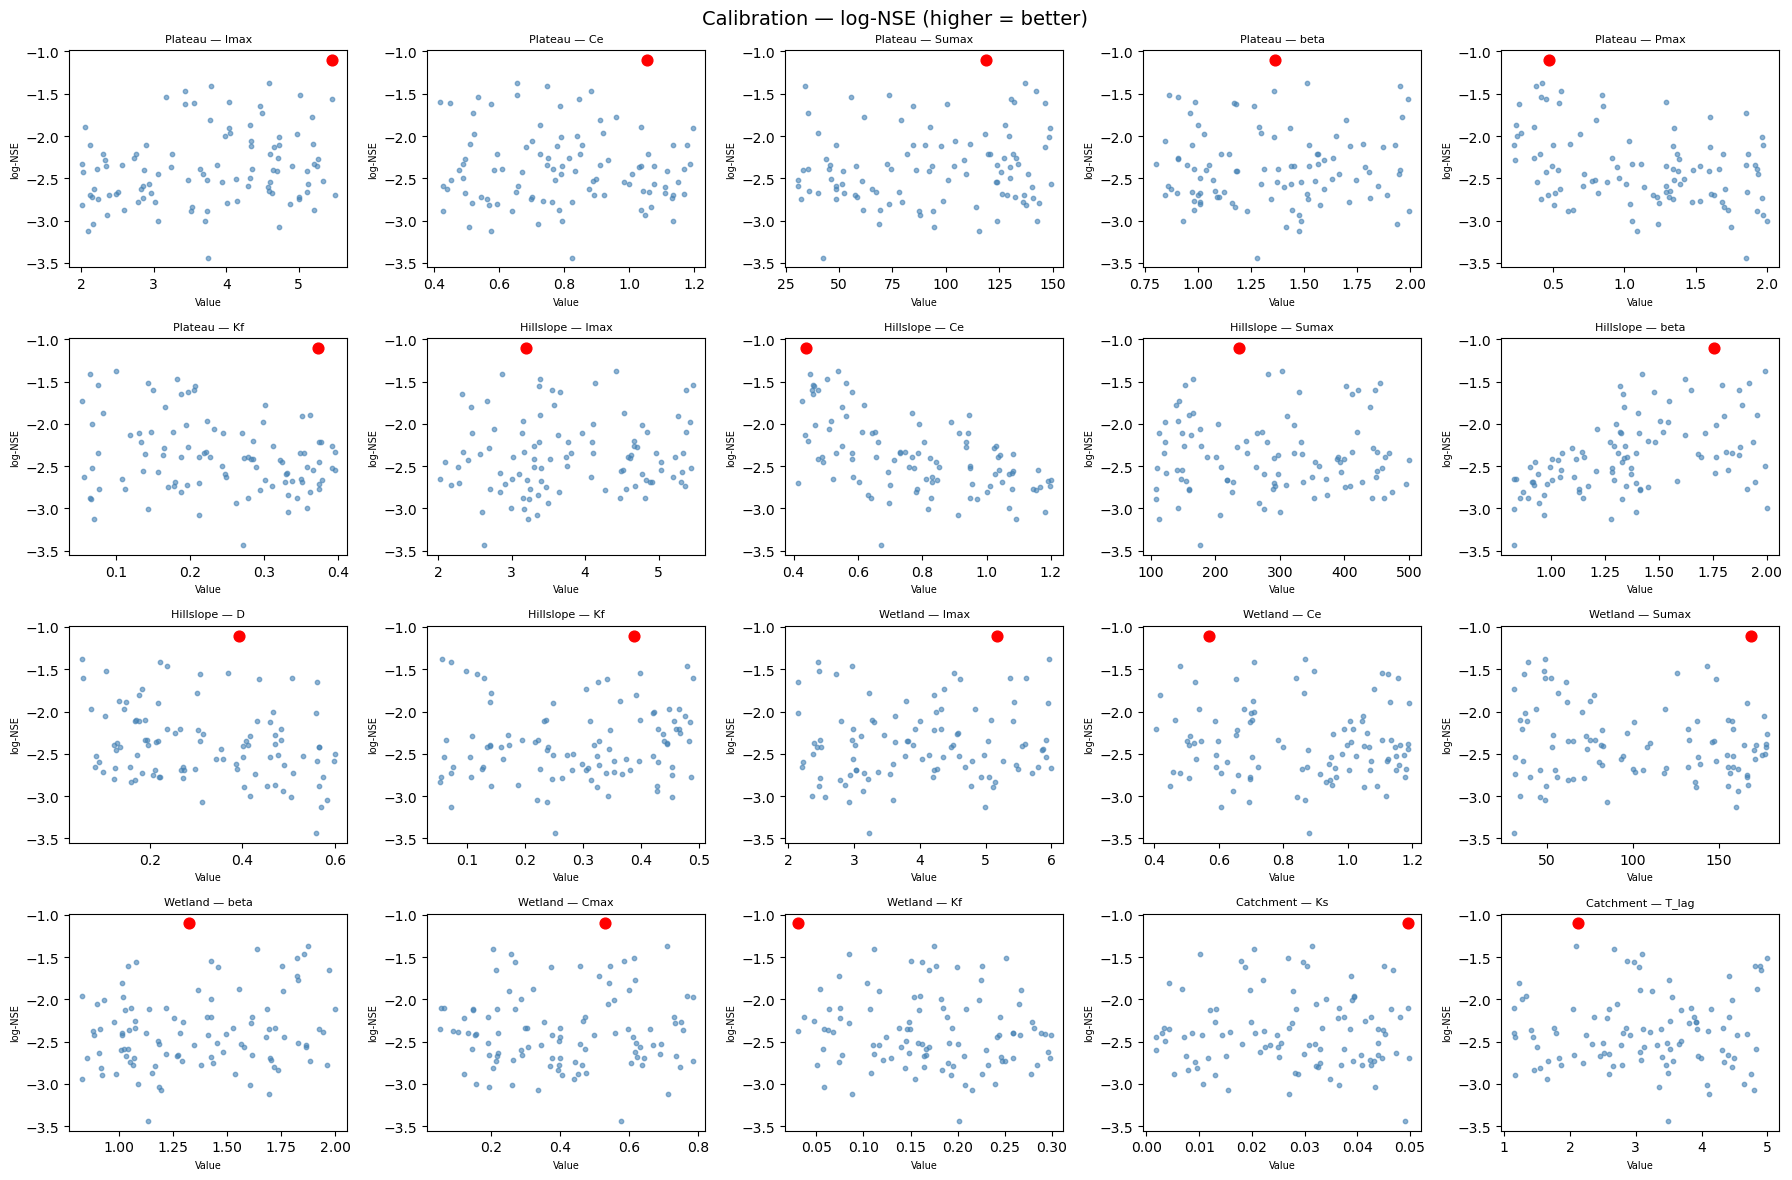

In [294]:
labels_plateau   = ['Imax', 'Ce', 'Sumax', 'beta', 'Pmax', 'Kf']
labels_hillslope = ['Imax', 'Ce', 'Sumax', 'beta', 'D',    'Kf']
labels_wetland   = ['Imax', 'Ce', 'Sumax', 'beta', 'Cmax', 'Kf']
labels_catchment = ['Ks', 'T_lag']

all_labels = (
    [f'Plateau — {l}'   for l in labels_plateau]   +
    [f'Hillslope — {l}' for l in labels_hillslope] +
    [f'Wetland — {l}'   for l in labels_wetland]   +
    [f'Catchment — {l}' for l in labels_catchment]
)

mae_scores     = results_df["MAE"].values
nse_values     = results_df["NSE"].values
log_nse_values = results_df["logNSE"].values

def dotty_plots(scores, title, ylabel, best_fn):
    n = min(len(parameter_ensemble), len(scores))
    params = parameter_ensemble[:n]
    scores = np.asarray(scores[:n], dtype=float)

    n_params = params.shape[1]
    ncols = 5
    nrows = -(-n_params // ncols)

    fig, axs = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
    fig.suptitle(title, fontsize=14)
    axs = axs.flatten()

    valid = np.isfinite(scores)
    valid_idx = np.where(valid)[0]
    best_local = best_fn(scores[valid])
    best_idx = valid_idx[best_local]

    for j in range(n_params):
        axs[j].scatter(params[valid, j], scores[valid], s=10, alpha=0.6, color='steelblue')
        axs[j].scatter(params[best_idx, j], scores[best_idx],
                       s=60, color='red', zorder=5, label='Best')
        axs[j].set_title(all_labels[j], fontsize=8)
        axs[j].set_xlabel('Value', fontsize=7)
        axs[j].set_ylabel(ylabel, fontsize=7)

    for j in range(n_params, len(axs)):
        axs[j].set_visible(False)

    plt.tight_layout()

dotty_plots(mae_scores,       'Calibration — MAE (lower = better)',       'MAE',     np.argmin)
dotty_plots(nse_values,       'Calibration — NSE (higher = better)',      'NSE',     np.argmax)
dotty_plots(log_nse_values,   'Calibration — log-NSE (higher = better)',  'log-NSE', np.argmax)

In [295]:
best_idx_mae    = np.nanargmin(mae_scores)
best_idx_nse    = np.nanargmax(nse_values)
best_idx_lognse = np.nanargmax(log_nse_values)

best_params_mae    = parameter_ensemble[best_idx_mae]
best_params_nse    = parameter_ensemble[best_idx_nse]
best_params_lognse = parameter_ensemble[best_idx_lognse]

def print_params(flat_p, label):
    print(f'\n{label}')
    print(f'  Plateau:    {dict(zip(labels_plateau,   np.round(flat_p[0:6], 4)))}')
    print(f'  Hillslope:  {dict(zip(labels_hillslope, np.round(flat_p[6:12], 4)))}')
    print(f'  Wetland:    {dict(zip(labels_wetland,   np.round(flat_p[12:18], 4)))}')
    print(f'  Catchment:  {dict(zip(labels_catchment, np.round(flat_p[18:20], 4)))}')

print_params(best_params_mae,    f'Best MAE     = {mae_scores[best_idx_mae]:.4f}')
print_params(best_params_nse,    f'Best NSE     = {nse_values[best_idx_nse]:.4f}')
print_params(best_params_lognse, f'Best log-NSE = {log_nse_values[best_idx_lognse]:.4f}')

Best MAE     = 0.3824

Plateau:    {'Imax': 5.4601, 'Ce': 1.0546, 'Sumax': 118.9938, 'beta': 1.3625, 'Pmax': 0.4752, 'Kf': 0.3722}

Hillslope:  {'Imax': 3.1949, 'Ce': 0.4401, 'Sumax': 236.9615, 'beta': 1.7533, 'D': 0.3925, 'Kf': 0.3879}

Wetland:    {'Imax': 5.1745, 'Ce': 0.5696, 'Sumax': 168.5675, 'beta': 1.3256, 'Cmax': 0.5293, 'Kf': 0.0306}

Catchment:  {'Ks': 0.0497, 'T_lag': 2.1236}

...

Best log-NSE = -1.1029

Plateau:    {'Imax': 5.4601, 'Ce': 1.0546, 'Sumax': 118.9938, 'beta': 1.3625, 'Pmax': 0.4752, 'Kf': 0.3722}

Hillslope:  {'Imax': 3.1949, 'Ce': 0.4401, 'Sumax': 236.9615, 'beta': 1.7533, 'D': 0.3925, 'Kf': 0.3879}

Wetland:    {'Imax': 5.1745, 'Ce': 0.5696, 'Sumax': 168.5675, 'beta': 1.3256, 'Cmax': 0.5293, 'Kf': 0.0306}

Catchment:  {'Ks': 0.0497, 'T_lag': 2.1236}

In [296]:
# =========================
# Validation
# =========================
Qo_val = df_val["Qo"].values

results_val = {}

for label, flat_p in [
    ('MAE', best_params_mae),
    ('NSE', best_params_nse),
    ('log-NSE', best_params_lognse)
]:
    Qm_val = run_flextopo_flat(flat_p, df_val, landscape_per)

    mae_v = mae_objective(Qm_val, Qo_val)
    nse_v, lognse_v = nse_objective(Qm_val, Qo_val)

    results_val[label] = {
        'Qm': Qm_val,
        'MAE': mae_v,
        'NSE': nse_v,
        'log-NSE': lognse_v
    }

    print(f'Calibrated on {label:8s} → validation MAE={mae_v:.4f}  NSE={nse_v:.4f}  log-NSE={lognse_v:.4f}')

Calibrated on MAE      → validation MAE=20.5007  NSE=-0.4721  log-NSE=-16.1019

Calibrated on NSE      → validation MAE=20.5007  NSE=-0.4721  log-NSE=-16.1019

Calibrated on log-NSE  → validation MAE=20.5007  NSE=-0.4721  log-NSE=-16.1019

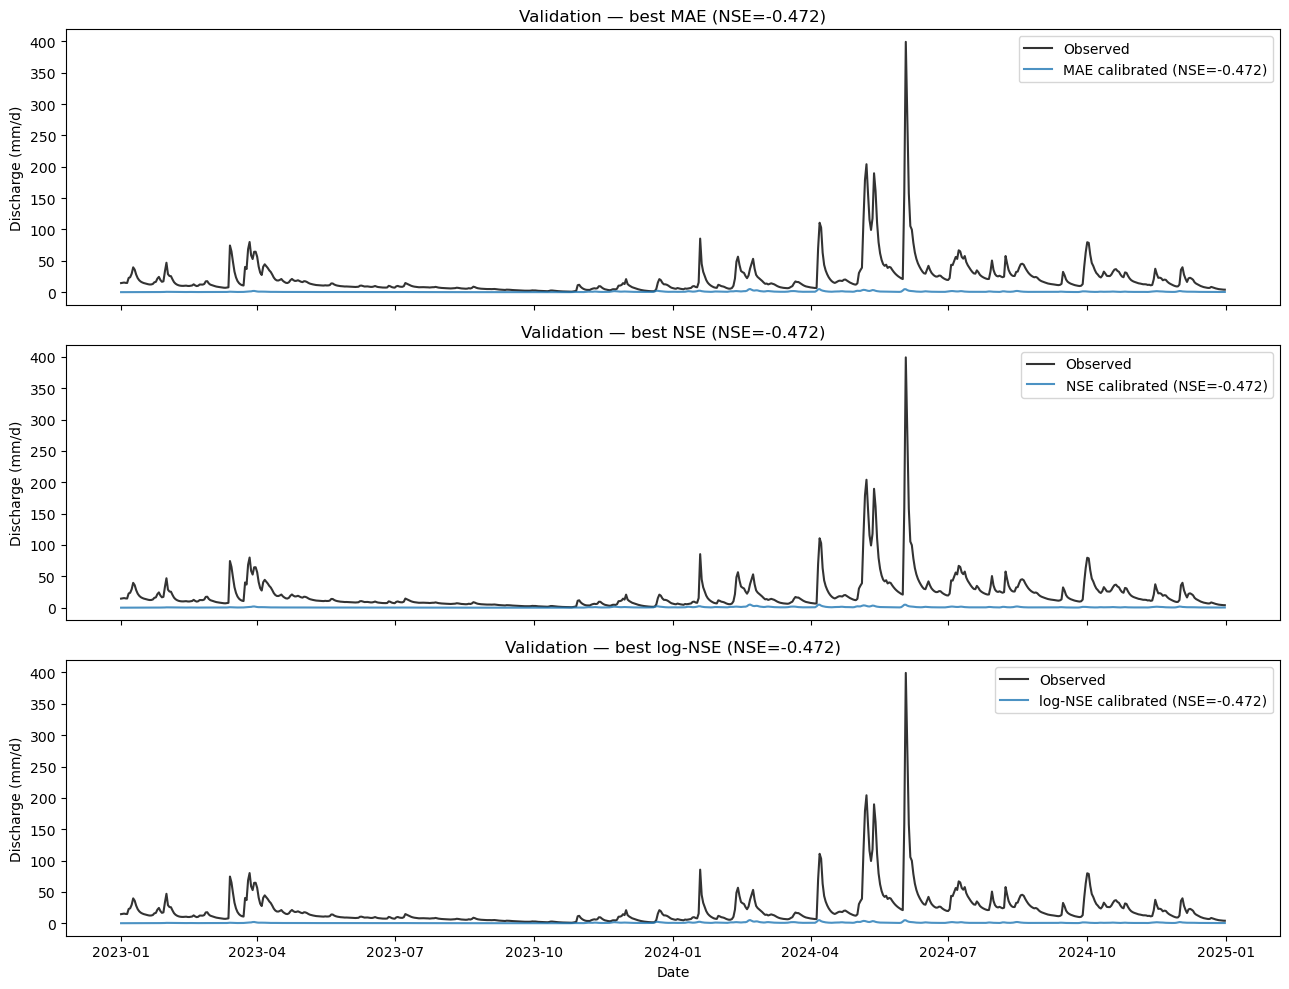

In [297]:
fig, axs = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, (label, out) in zip(axs, results_val.items()):
    n_plot = min(len(df_val), len(out["Qm"]))

    ax.plot(df_val.index[:n_plot],
            df_val["Qo"].values[:n_plot],
            label="Observed",
            color="black",
            alpha=0.8)

    ax.plot(df_val.index[:n_plot],
            out["Qm"][:n_plot],
            label=f'{label} calibrated (NSE={out["NSE"]:.3f})',
            alpha=0.8)

    ax.set_title(f'Validation — best {label} (NSE={out["NSE"]:.3f})')
    ax.set_ylabel("Discharge (mm/d)")
    ax.legend()

axs[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [298]:
                  #      I_max Ce Su_max beta Pmax    Kf  
ParPlateau   = np.array([3.2, 0.50, 17.40, 0.95, 1.76, 0.91])   
                  #      I_max Ce Su_max beta D     Kf  
ParHillslope = np.array([3.25, 0.50, 321.99, 0.99, 0.4, 0.97])
                  #      I_max Ce Su_max beta C_max     Kf  
ParWetland   = np.array([9.94, 0.50, 53.25, 0.70, 0.65, 0.45])
              # Ks T_lag
ParCatchment = np.array([0.0281, 2.21])

'''UPDATE'''
# Landscape percentages
landscape_per = np.array([plateau_per, hillslope_per, wetland_per])

## Calculate the discharge 

Use the FLEXtopo model to calculate the discharge. Plot it together with the measured discharge.

Compare these results to the results you got from calculating the discharge with the HBVmodel (see “Lumped Models: Model Excersise2: Lumped Conceptual Model”). Where are the main differences in the hydrograph? Which processes are causing this?


In [300]:
# Run FLEXtopo with the merged forcing dataframe

Qm = FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscape_per)
Qo = forcing["Qo"]

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(forcing.index, Qm, label='Modelled')
ax.plot(forcing.index, Qo, label='Observed')


ax.legend()
ax.set_title('Discharge - FLEXtopo')
ax.set_xlabel('Date')
ax.set_ylabel('Flow')


KeyError: 'Qo'